# **MÓDULO 18 - Regressão Linear**

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1 Coleta de dados

In [2]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 2 Verificação inicial

## 2.1 Tipos de dados

In [3]:
# Quantidade de linhas colunas
df.shape

(7203, 7)

In [4]:
#Verificando os tipos de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


## 2.2 Dados faltantes

In [5]:
# Verificando dados faltantes
df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

Ao verificar os tipos de dados, observa-se que todas as variáveis estão em formato numérico, o que é adequado para a aplicação de regressão linear.
Na análise de dados faltantes, nota-se que não há valores ausentes na base, portanto não foi necessário realizar tratamento de imputação ou remoção de registros.

# 3 Análise Exploratória dos dados

## 3.1 Análise univariada

### 3.1.1 Análise estatística

In [6]:
# Verificando os dados estatísticos
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


In [7]:
# Na estatística uma dispersão é considerada baixa, moderada ou alta a partir do seu coeficiente de variação (CV), que é o desvio padrão 
# dividido pela a média:
# CV <= 10% -> dispersão baixa
# 10% < CV <= 30% -> dispersão moderada
# CV > 30% -> dispersão alta

# logo vamos calcular o CV de cada variável numérica.

for column in df:
    coefficient_of_variation = (df[column].std() / df[column].mean()) * 100
    print(f"Coeficiente de variação da variável {column}: {coefficient_of_variation:.2f}")

Coeficiente de variação da variável Valor_Aluguel: 99.40
Coeficiente de variação da variável Valor_Condominio: 98.15
Coeficiente de variação da variável Metragem: 69.56
Coeficiente de variação da variável N_Quartos: 35.94
Coeficiente de variação da variável N_banheiros: 46.94
Coeficiente de variação da variável N_Suites: 85.99
Coeficiente de variação da variável N_Vagas: 60.34


É possível ver na tabela describe() que:

* A variável **Valor_Aluguel** apresenta **grande amplitude**, variando de **480** a **25000**. Seu **coeficiente de variação** é de aproximadamente **99,4%**, indicando alta dispersão e forte heterogeneidade nos dados. O **intervalo interquartil** é de **1850**, mostrando que os **50%** centrais dos valores estão concentrados em uma faixa relativamente menor que a amplitude total, o que sugere a presença de valores extremos. Além disso, como a média é maior que a mediana, há indícios de assimetria à direita, com imóveis de aluguel muito alto puxando a média para cima.
* A variável **Valor_Condomínio** varia de **0** a **9500** e possui intervalo interquartil de **585**, também bem inferior à amplitude total. Isso sugere concentração dos valores centrais em faixas mais baixas e possível presença de valores extremos. O coeficiente de variação elevado reforça a alta dispersão dessa variável.
* Na variável **Metragem**, os valores vão de **30** a **880**, indicando grande variedade no tamanho dos imóveis. O intervalo interquartil é relativamente menor que a amplitude, o que também pode indicar valores extremos. Como a média é superior à mediana, há indícios de assimetria à direita.
* As variáveis **N_Quartos**, **N_banheiros**, **N_Suites** e **N_Vagas** apresentam médias próximas, mas levemente superiores às medianas, sugerindo leve assimetria à direita. Em geral, os imóveis estão concentrados em perfis mais padronizados, com cerca de **2 quartos**, **2 banheiros**, **1 suíte** e **1** a **2 vagas**, embora existam alguns imóveis com características muito acima desse padrão.

### 3.1.2 Verificar e tratar outliers

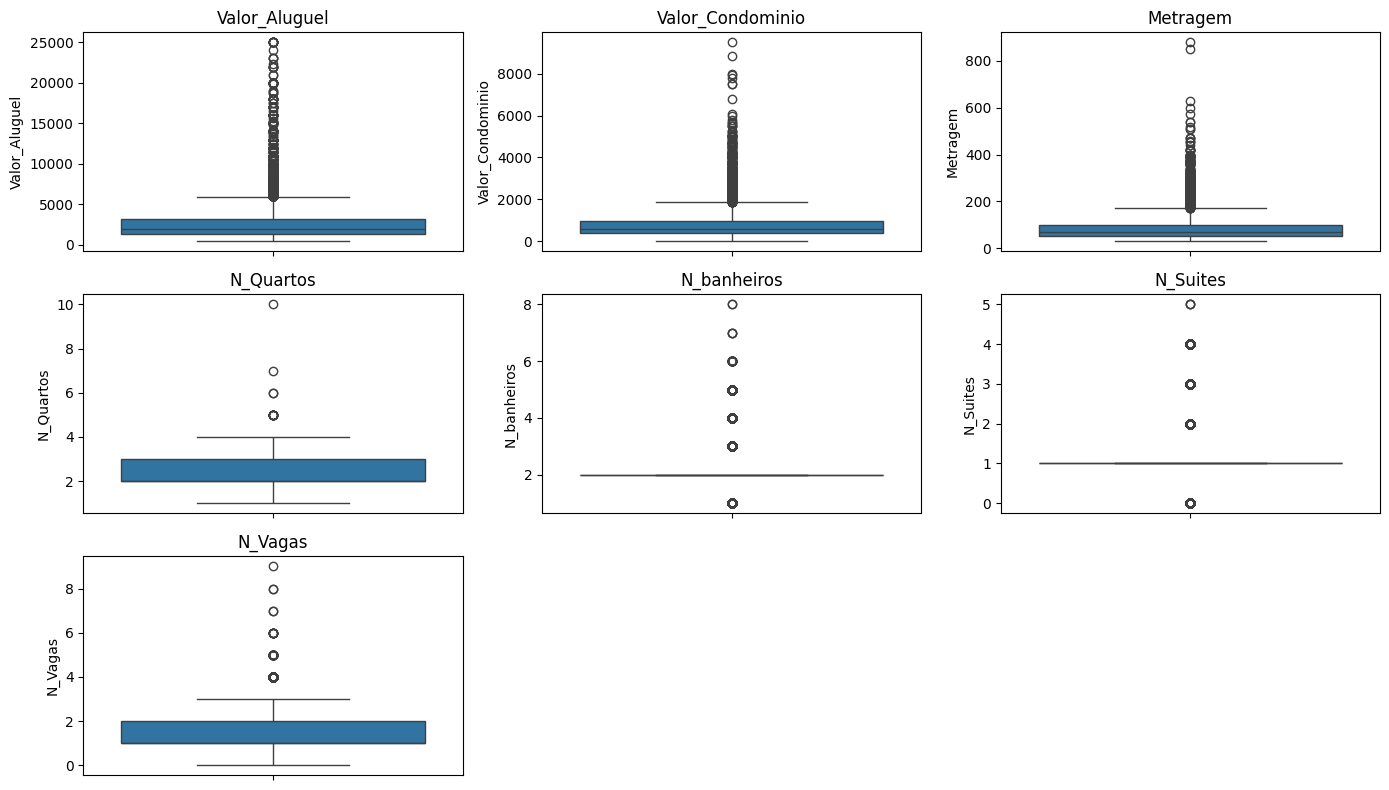

In [8]:
# Boxplots individuais
plt.figure(figsize=(14,8))
for i, coluna in enumerate(df.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[coluna])
    plt.title(coluna)
plt.tight_layout()
plt.show()

Os boxplots indicam a presença de valores extremos nas variáveis **Valor_Aluguel**, **Valor_Condominio** e **Metragem**. No entanto, optou-se por não remover esses valores, pois eles podem representar imóveis reais de alto padrão. Como a base se refere ao mercado imobiliário, esses registros podem fazer parte da variabilidade natural dos dados. Assim, os outliers foram mantidos e considerados na interpretação dos resultados.

Além disso, como a variável **Valor_Condominio** apresenta valor mínimo igual a **0**, foi realizada uma investigação complementar para verificar se esse valor poderia representar erro, ausência de informação ou uma característica real dos imóveis anunciados.

In [9]:
# Quantidade de imóveis com condomínio igual a 0
(df['Valor_Condominio'] == 0).sum()

np.int64(638)

In [10]:
# Percentual de imóveis com condomínio igual a 0
((df['Valor_Condominio'] == 0).sum() / len(df)) * 100

np.float64(8.8574205192281)

In [11]:
# Visualizando algumas linhas com condomínio zero
df[df['Valor_Condominio'] == 0].head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
4,500,0,30,1,1,0,0
10,600,0,90,1,2,1,1
22,650,0,40,1,2,1,1
24,650,0,38,1,2,1,1
26,650,0,30,2,2,1,1
28,650,0,48,2,2,1,1
35,700,0,30,1,2,1,1
37,700,0,48,2,2,1,1


A variável **Valor_Condominio** apresenta valor mínimo igual a **0**. Ao investigar a base, observou-se que **638 imóveis** possuem condomínio igual a zero, o que corresponde a aproximadamente **8,86%** dos registros. Esse valor pode representar imóveis sem cobrança de condomínio ou casos em que a informação não foi preenchida. Como não há evidências suficientes para classificar esses registros como erro, optou-se por mantê-los na base, apenas destacando essa particularidade na análise.

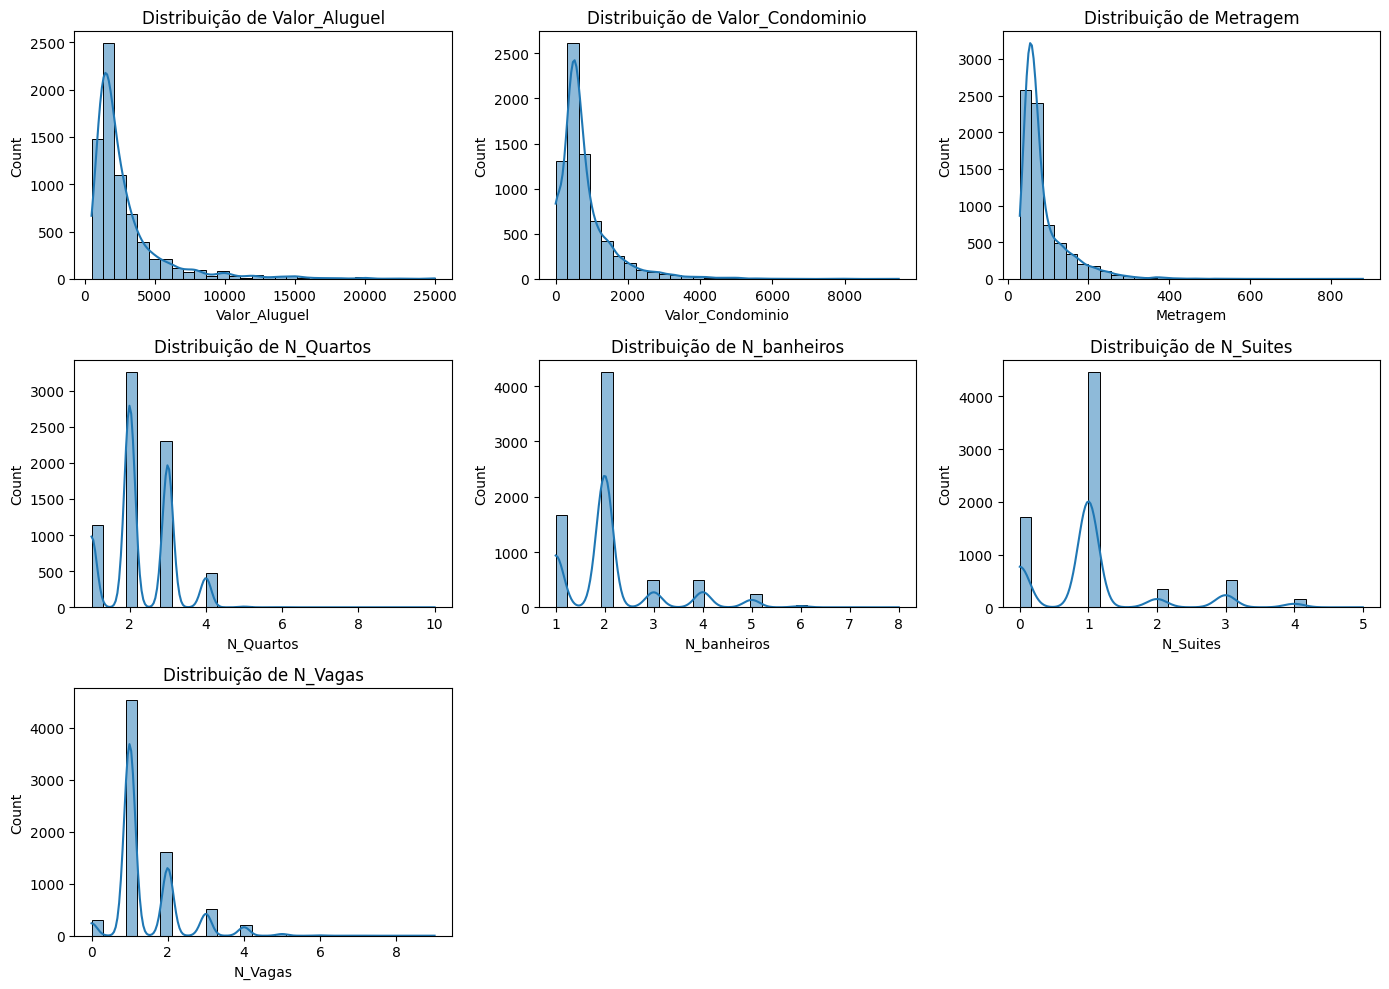

In [12]:
# Histogramas das variáveis
plt.figure(figsize=(14,10))
for i, coluna in enumerate(df.columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(x=df[coluna], bins=30, kde=True)
    plt.title(f'Distribuição de {coluna}')
plt.tight_layout()
plt.show()

Os histogramas mostram que as variáveis **Valor_Aluguel**, **Valor_Condominio** e **Metragem** apresentam **distribuição assimétrica à direita**, com maior concentração de imóveis em valores mais baixos e presença de uma cauda longa, indicando poucos registros com valores muito elevados. Esse comportamento reforça os indícios de alta dispersão e existência de valores extremos já observados na análise estatística e nos boxplots.

Já as variáveis **N_Quartos**, **N_banheiros**, **N_Suites** e **N_Vagas** apresentam distribuições mais concentradas em poucos valores inteiros, o que é esperado por se tratarem de variáveis discretas. Observa-se maior frequência de imóveis com **2 quartos**, **2 banheiros**, **1 suíte** e **1 vaga**, indicando que a maior parte da base é composta por imóveis com perfil mais padronizado.

De forma geral, os histogramas confirmam que a base possui maior concentração de imóveis com características intermediárias e poucos imóveis com valores ou dimensões muito acima do padrão.

## 3.2 Análise bivariada

### 3.2.1 Existe relação entre a Metragem e o Valor do Aluguel?

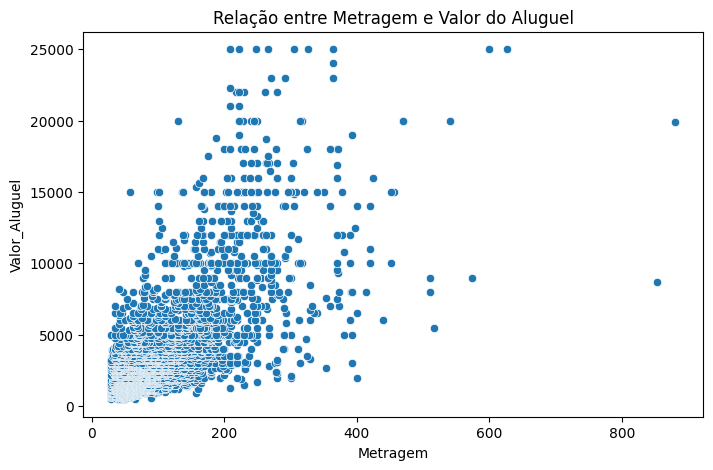

In [13]:
# Dispersão entre metragem e valor do aluguel
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Metragem'], y=df['Valor_Aluguel'])
plt.title('Relação entre Metragem e Valor do Aluguel')
plt.xlabel('Metragem')
plt.ylabel('Valor_Aluguel')
plt.show()

O gráfico de dispersão entre Metragem e Valor_Aluguel sugere uma relação positiva entre as variáveis, indicando que, em geral, imóveis com maior metragem tendem a apresentar valores de aluguel mais altos. No entanto, observa-se uma dispersão considerável dos pontos, o que mostra que a metragem, sozinha, não explica totalmente o valor do aluguel. Isso sugere que outras características do imóvel também influenciam o preço.

### 3.2.2 Existe relação entre Valor do Condominio e o Valor do Aluguel

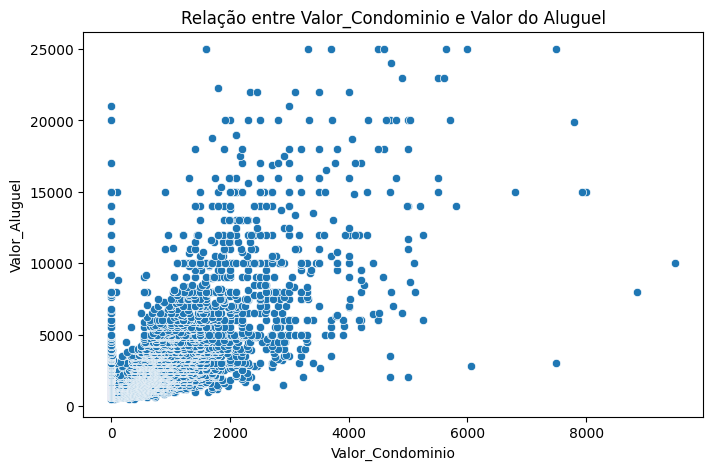

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Valor_Condominio'], y=df['Valor_Aluguel'])
plt.title('Relação entre Valor_Condominio e Valor do Aluguel')
plt.xlabel('Valor_Condominio')
plt.ylabel('Valor_Aluguel')
plt.show()

O gráfico de dispersão entre **Valor_Condominio** e **Valor_Aluguel** sugere uma **relação positiva** entre as variáveis, indicando que imóveis com condomínio mais elevado tendem, em geral, a apresentar aluguel mais alto. No entanto, observa-se dispersão considerável entre os pontos, o que mostra que o valor do condomínio, isoladamente, não explica totalmente o preço do aluguel.

### 3.2.3 Existe relação entre o Valor_Aluguel e N_Quartos

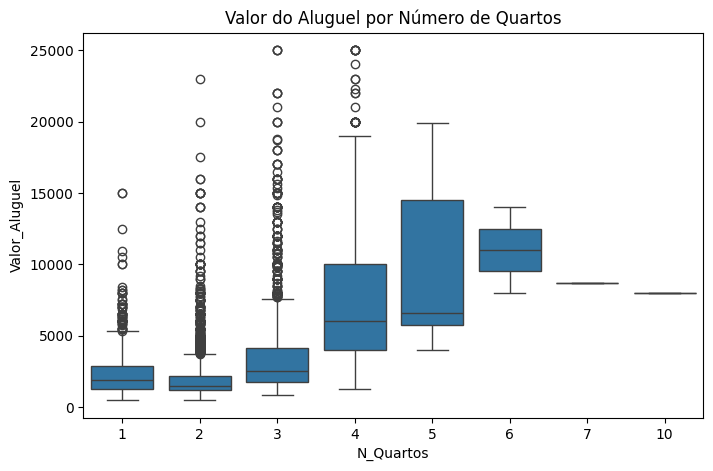

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['N_Quartos'], y=df['Valor_Aluguel'])
plt.title('Valor do Aluguel por Número de Quartos')
plt.xlabel('N_Quartos')
plt.ylabel('Valor_Aluguel')
plt.show()

O boxplot do **Valor_Aluguel** por **N_Quartos** indica que imóveis com maior número de quartos tendem a apresentar aluguel mais elevado. No entanto, há sobreposição entre as distribuições dos grupos, mostrando que o número de quartos contribui para explicar o preço, mas não é o único fator determinante.

# 4  Correlação

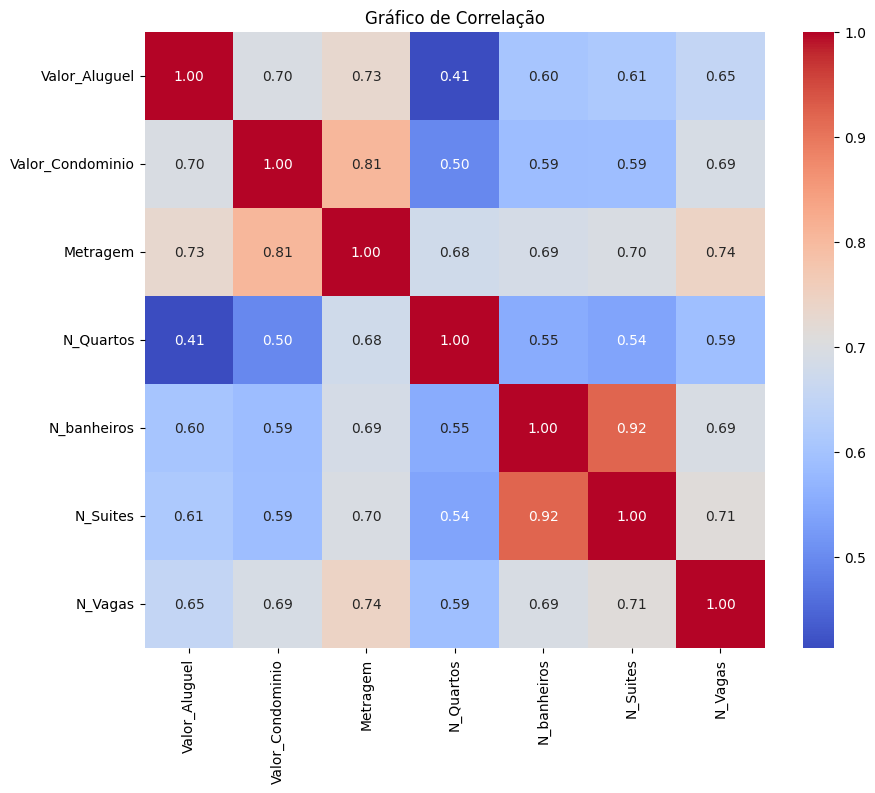

In [16]:
# Calculando a matriz de correlação
correlation = df.corr()

# Gráfico:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Gráfico de Correlação')
plt.show()

In [17]:
# Correlação das variáveis com o valor do aluguel
correlation_aluguel = correlation['Valor_Aluguel'].sort_values(ascending=False)
correlation_aluguel

Valor_Aluguel       1.000000
Metragem            0.730591
Valor_Condominio    0.695302
N_Vagas             0.652858
N_Suites            0.614397
N_banheiros         0.603715
N_Quartos           0.413139
Name: Valor_Aluguel, dtype: float64

As variáveis **Metragem** e **Valor_Condominio** apresentam as correlações mais fortes com **Valor_Aluguel**, com valores aproximados de **0,73** e **0,70**, respectivamente. Em seguida, aparecem **N_Vagas (0,65)**, **N_Suites (0,61)** e **N_banheiros (0,60)**, todas com correlação positiva moderada. Já **N_Quartos** apresentou correlação mais fraca com a variável alvo, em torno de **0,41**.

Isso indica que imóveis maiores, com maior condomínio, mais vagas, suítes e banheiros tendem a apresentar aluguel mais alto.

Também é importante observar que algumas variáveis independentes possuem correlação forte entre si, como **N_banheiros** e **N_Suites**, o que pode indicar certa multicolinearidade no modelo múltiplo.

# 5 Separação entre treino e teste

In [18]:
# Separando X e y
X = df.drop('Valor_Aluguel', axis=1)
y = df['Valor_Aluguel']

# Separando treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5042, 6)
X_test: (2161, 6)
y_train: (5042,)
y_test: (2161,)


# 6 Aplicação dos Modelos

## 6.1 Regressão Linear Simples

Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [19]:
X = X_train[['Metragem']]  # Variável independen
y = y_train  # Variável dependente

In [20]:
# Criando e treinando o modelo
simple_model = LinearRegression()
simple_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
intercept = simple_model.intercept_
coefficient = simple_model.coef_[0]

print("Intercepto:", intercept)
print("Coeficiente:", coefficient)
print(f'Equação da reta: Valor_Aluguel = {coefficient:.2f} + ({coefficient:.2f} * Metragem)')

Intercepto: -90.4636457339002
Coeficiente: 34.483748266883225
Equação da reta: Valor_Aluguel = 34.48 + (34.48 * Metragem)


Nossa equação seria:
**Valor_Aluguel = intercepto + coeficiente × Metragem**

Isso significa que, para cada aumento de 1 unidade na metragem, o valor estimado do aluguel varia conforme o coeficiente encontrado pelo modelo.

In [22]:
r2_simple_model = simple_model.score(X, y)
print("Coeficiente de Determinação (R²) nos Dados de Treino:", r2_simple_model)

Coeficiente de Determinação (R²) nos Dados de Treino: 0.5175003940731389


O valor de **R²** no treino mostra o quanto a variável **Metragem** consegue explicar a variação do **Valor_Aluguel** nos dados de treinamento. Como o modelo utiliza apenas uma variável explicativa, espera-se um poder preditivo razoável, mas limitado.

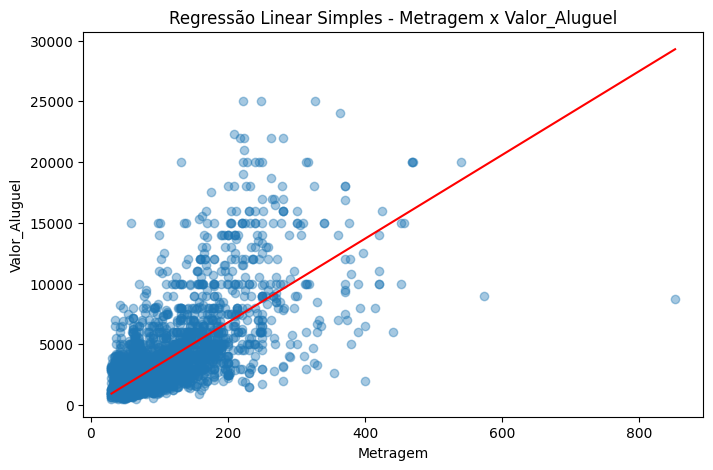

In [23]:
# Ordenando os valores para desenhar a reta corretamente
X_ordered = X.sort_values(by='Metragem')

plt.figure(figsize=(8,5))
plt.scatter(X['Metragem'], y, alpha=0.4)
plt.plot(X_ordered['Metragem'], simple_model.predict(X_ordered), color='red')
plt.title('Regressão Linear Simples - Metragem x Valor_Aluguel')
plt.xlabel('Metragem')
plt.ylabel('Valor_Aluguel')
plt.show()

O gráfico mostra uma **tendência positiva** entre **Metragem** e **Valor_Aluguel**, indicando que imóveis maiores tendem a ter aluguel mais alto. No entanto, a dispersão dos pontos ao redor da reta mostra que a metragem sozinha não explica completamente o preço dos imóveis.

In [24]:
X_test = X_test[['Metragem']]  # Variável independente
y_test = y_test  # Variável dependente

In [25]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
predictions = simple_model.predict(X_test)

# Avaliando o desempenho do modelo usando a métrica R²
r2 = simple_model.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)

Coeficiente de Determinação (R²) nos Dados de Teste: 0.5667730731423721


O modelo de **regressão linear simples** apresentou **desempenho razoável**, mostrando que a variável **Metragem possui** relação importante com o **valor do aluguel**. No entanto, como o preço de um imóvel depende de vários fatores além do tamanho, o modelo simples possui capacidade explicativa limitada.

Ao comparar os valores de **R²** no **treino** e no **teste**, são relativamente próximos, pois isso indica que o modelo consegue generalizar de forma satisfatória para novos dados. Mesmo assim, como o modelo utiliza apenas uma variável, ele não consegue capturar toda a complexidade envolvida na formação do preço do aluguel.

## 6.2 Modelo de regressão linear multipla!

In [26]:
# Separando novamente todas as variáveis independentes
X = df.drop('Valor_Aluguel', axis=1)
y = df['Valor_Aluguel']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (5042, 6)
X_test: (2161, 6)


In [27]:
multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
coefficient = pd.DataFrame({
    'Variavel': X_train.columns,
    'Coeficiente': multiple_model.coef_
})

coefficient

,Variavel,Coeficiente
0,Valor_Condominio,0.781434
1,Metragem,20.386618
2,N_Quartos,-669.242526
3,N_banheiros,228.198870
4,N_Suites,346.652046
5,N_Vagas,544.422265


In [29]:
r2_multiple_model = multiple_model.score(X_train, y_train)
print("Coeficiente de Determinação (R²) nos Dados de Treino:", r2_multiple_model)

Coeficiente de Determinação (R²) nos Dados de Treino: 0.5956434956405704


O modelo de **regressão linear múltipla** apresentou um valor de **R² maior no treino em comparação ao modelo simples**, indicando melhor capacidade de explicar a variação do valor do aluguel. Isso ocorre porque o modelo considera simultaneamente várias características dos imóveis.

In [30]:
previsoes_multiplo = multiple_model.predict(X_test)
r2_multiple_model = multiple_model.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2_multiple_model)

Coeficiente de Determinação (R²) nos Dados de Teste: 0.6307353793799015


# 7 Comparando os modelos

Comparando os resultados, o **modelo de regressão linear múltipla** apresentou desempenho melhor do que o modelo de regressão linear simples.

Enquanto a **regressão simples** utilizou apenas a variável **Metragem**, a **regressão múltipla** considerou também **Valor_Condominio**, **N_Quartos**, **N_banheiros**, **N_Suites** e **N_Vagas**, o que permitiu representar melhor os diferentes fatores que influenciam o **valor do aluguel**.

Por isso, o **R²** do modelo múltiplo foi maior, mostrando **maior capacidade explicativa** e **melhor desempenho preditivo**. Assim, o modelo múltiplo se mostrou mais adequado para prever o valor do aluguel dos imóveis dessa base.